In [1]:
# import all packages
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd

# Read roadway lengths

In [2]:
folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\Streets_df\All states'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    # print(file)
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df_state = pd.read_csv(file_path, index_col =0)
    # to check how many places are excluded
    # print(df_state.shape[0])
    # count = count + df_state.shape[0]
    df_state['GEOID'] = df_state['GEOID'].astype(str).str.rjust(7, '0')
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df_state], ignore_index=True)
print(concatenated_df.shape)

# 13 missing places due to missing geometry
# Total no of places for 50 states in 2020
# 31249+13 = 31262

(31249, 16)


In [3]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape)

(32188, 17)
(31262, 17)


<Axes: >

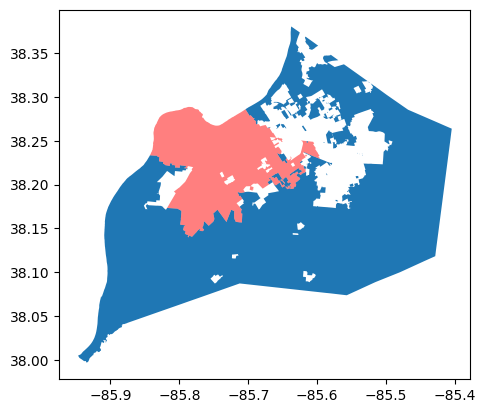

In [4]:
ax = places_50_states[places_50_states['GEOID'] == '2148006'].plot() # 	Louisville/Jefferson County metro government 
places_50_states[places_50_states['GEOID'] == '2148000'].plot(ax=ax, color='red', alpha = 0.5) # 	Louisville city

In [5]:
# concatenated_df.dtypes
concatenated_df.head()

,GEOID,NAMELSAD,motorway,trunk,primary,secondary,tertiary,unclassified,residential,cl_motorway,cl_trunk,cl_primary,cl_secondary,cl_tertiary,cl_unclassified,cl_residential
0,0102260,Ardmore town,0,0,[4982.59329295],[4515.60248183],[3414.7747859],[4679.35177942],[37801.08648814],0,0,[2491.29664647],[2276.2207127],[1707.38739295],[2339.67588971],[18935.83231101]
1,0151264,Mooresville town,[136.16154155],0,0,0,[1221.0092178],0,[4847.4987655],[136.16154155],0,0,0,[610.5046089],0,[2454.80585472]
2,0171496,Somerville town,0,0,0,[16702.05036983],0,0,[42007.38767528],0,0,0,[8351.02518492],0,0,[20623.51394204]
3,0176872,Trinity town,0,[3921.7328301],0,0,[24753.43964382],[3779.4748859],[64473.20671685],0,[3921.7328301],0,0,[12376.71982191],[1889.73744295],[31451.06650643]
4,0130880,Goshen town,0,0,0,0,[12662.95531831],[2292.40449468],[16229.56523005],0,0,0,0,[6331.47765916],[1146.20224734],[8114.78261503]


In [6]:
df = concatenated_df.copy()

In [7]:
# Convert link lengths from str of list elements to float 
def str_to_float(df, column_name):
    return df[column_name].str.replace("[","").str.replace("]","").astype(float)

column_list = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 
               'cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']


for column in column_list:
    df[column] = str_to_float(df, column)

In [8]:
# Calculate total roadway length and total centerline roadway length
roadway_columns = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential']
cl_roadway_columns = ['cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']

df['total_length'] = df[roadway_columns].sum(axis=1)
df['cl_total_length'] = df[cl_roadway_columns].sum(axis=1)

In [9]:
# NaNs values in roadway length dataframe
df.isna().sum().sum()

0

# Import population and attributes data from depopulation study

In [10]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi']], on = 'GEOID')
print(df_population.shape, df_attributes.shape, df_pop_attr.shape)

(31617, 58) (31908, 33) (31616, 61)


In [11]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

# Merge roads with population

In [12]:
roads_with_pop = df.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi',
                                       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                       'ssp22090','ssp22100']], on = 'GEOID', how='left')
roads_with_pop.shape

(31249, 34)

In [13]:
roads_with_pop[roads_with_pop['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']]
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

,GEOID,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050
10245,2148006,Louisville/Jefferson County metro government (...,386884.0,389068.4372,424417.2341,456660.9352,485264.1312
10405,2148000,Louisville city,NaN,NaN,NaN,NaN,NaN


In [14]:
print('Total population in millions for 50 states: ===')
roads_with_pop[['CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 50 states: ===


CensusPop_20    248.779899
ssp22020        250.287579
ssp22030        270.511862
ssp22040        288.564911
ssp22050        304.282673
ssp22060        319.590817
ssp22070        333.443879
ssp22080        343.642158
ssp22090        349.691666
ssp22100        352.378215
dtype: float64

### Read redefined urban rural classes

In [15]:
df_urban_rural_conn = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\buildings_output.csv')
df_urban_rural_conn = df_urban_rural_conn[['GEOID','citytype_at_2030',  'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060']]
df_urban_rural_conn['GEOID'] = df_urban_rural_conn['GEOID'].astype(str).str.rjust(7,'0')

### Fit scale law

In [16]:
# fit the total population and total infrastructure data in the scaling law 
def find_scale_parameters(df, infra_col, pop_col):
    df.loc[:,'log_pop_col'] = np.log(df[pop_col].astype(float))
    df.loc[:, 'log_infra_col'] = np.log(df[infra_col].astype(float))

    # To get an interactive plot
    # fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
    #                 width=800, height=800) 
    # fig.show()

    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    print(model.summary())
    print(model.params)
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params

### Find next stock

In [17]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

def find_next_stock(df, current_stock_col, current_pop_col, next_pop_col, citytype):
    print(f"Initial dataframe:====")
    print(df.shape)
    
    df_stocks_iter = pd.DataFrame()

    if t == 2030:
        citytype_col = 'city type'
    else:
        citytype_col = 'citytype_at_' + str(t-10)
    
    df['per_cap_mass_t1'] = df[current_stock_col] / df[current_pop_col]
    df_nonzero = df[df[current_pop_col] !=0]
    df_nonzero_city = df_nonzero[df_nonzero[citytype_col] == citytype]
    print(f"Shape of the dataframe for {citytype}:====")
    print(df_nonzero_city.shape)
    

    print("Prune upper and lower 10 percent data before fitting to the scaling law")
    print("***DEFINITELY NEED TO VALIDATE THIS PRUNING***")
    ### ============== PRUNING ============== ### top and bottom 10 %
    # Set the threshold to the 90th percentile
    threshold_upper = df_nonzero_city[current_stock_col].quantile(0.9)
    threshold_lower = df_nonzero_city[current_stock_col].quantile(0.1)
    # Filter the DataFrame to include only points in the to middle 80%
    df_for_fitting = df_nonzero_city[df_nonzero_city[current_stock_col] < threshold_upper]
    df_for_fitting = df_nonzero_city[df_nonzero_city[current_stock_col] > threshold_lower]
    print("Shape of dataframe used in scaling fit:===")
    print(df_for_fitting.shape)

    # Fit the log-log linear model
    x = find_scale_parameters(df_for_fitting, infra_col= current_stock_col, pop_col = current_pop_col)

    # Get the model parameters
    # Set the range for the uniform distribution
    log_a_lower = x[0][0]
    log_a_upper= x[0][1]

    beta_lower = x[1][0]
    beta_upper= x[1][1]

    print("Using the coefficient found from scaling law for the complete dataframe:===")
    # Create an empty column of stocks at next time step
    df_nonzero_city.loc[:,'stock_at_t2'] = np.nan
    df_nonzero_city.loc[:,'stocks_at_reg'] = np.nan

    df_stocks_iter = df_nonzero_city[['GEOID', 'NAMELSAD']]

    # Randomly sample loga and beta values
    def sample_coeff():
        beta = np.random.choice(beta_uniform, size=1)
        return beta

    for i in range(10):
        # Sampling coefficient beta from and uniform distribution
        beta_uniform = np.random.uniform(low=beta_lower, high=beta_upper, size=100000)     
        for index, row in df_nonzero_city.iterrows():
            beta = sample_coeff()
            # IF loga CHNAGES WITH EACH TIME STEP
            log_a = np.log(row[current_stock_col] / row[current_pop_col])
            # IF loga IS CONSTANT WITH EACH TIME STEP
            # log_a = np.log(row['surface_2020'] / row['CensusPop_20'])
            # print(log_a, beta)
            df_nonzero_city.at[index,'stocks_at_reg'] = np.exp(log_a) * (row[current_pop_col] ** beta)
            if row[next_pop_col] >= row[current_pop_col]:
                df_nonzero_city.at[index,'stocks_at_t2'] = np.exp(log_a) * (row[next_pop_col] ** beta)
            else:
                df_nonzero_city.at[index,'stocks_at_t2'] = 0

        df_nonzero_city.loc[:,'added_stock'] = np.where(df_nonzero_city['stocks_at_t2'] == 0, 0, (df_nonzero_city['stocks_at_t2'] - df_nonzero_city['stocks_at_reg']))
        df_nonzero_city.loc[:,'stock_next_time_step'] = (df_nonzero_city[current_stock_col] + df_nonzero_city['added_stock'])
        df_nonzero_city.loc[:,'per_cap_mass_next_time_step'] = (df_nonzero_city[current_stock_col] + df_nonzero_city['added_stock'])/df_nonzero_city[next_pop_col] 

        df_stocks_iter = pd.concat([df_stocks_iter, df_nonzero_city[['per_cap_mass_next_time_step', 'stock_next_time_step']]], axis=1)

    return df_stocks_iter

In [18]:
print('Total NaNs in population and roadway length:===')
print(roads_with_pop[['CensusPop_20', 'ssp22040', 'total_length']].isna().sum())
print("Places with no roadway:===", roads_with_pop[roads_with_pop['cl_total_length'] == 0].shape[0])
print("Places with zero population in census 2020:===", roads_with_pop[roads_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", roads_with_pop[roads_with_pop['ssp22040'].isnull()].shape[0])
print(roads_with_pop.shape)

Total NaNs in population and roadway length:===
CensusPop_20     1
ssp22040        42
total_length     0
dtype: int64
Places with no roadway:=== 0
Places with zero population in census 2020:=== 41
Places with no available population forecast:=== 42
(31249, 34)


In [19]:
roads_clean = roads_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'total_length', 'cl_total_length']).reset_index(drop=True)
roads_clean['per_cap_mass_20'] = roads_clean['cl_total_length'] / roads_clean['CensusPop_20']
print("Shape of the clean dataset with nonzero values:==")
print(roads_clean.shape)
roads_clean = roads_clean.merge(df_urban_rural_conn, on ='GEOID')
print("Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==")
print(roads_clean.shape)

Shape of the clean dataset with nonzero values:==
(31207, 35)
Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==
(31169, 39)


### Run loops 

In [20]:
def process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t):
    print(df_for_analysis.shape)
    # run the fitting model for each city type
    df_2040_urban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[0])
    df_2040_suburban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[1])
    df_2040_periurban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[2])
    df_2040_rural = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[3])

    df_all_types = pd.concat([df_2040_urban, df_2040_suburban, df_2040_periurban, df_2040_rural], axis =0)

    per_cap_mass_at_t = 'per_cap_mass_at_' + str(t)
    surface_Res_at_t = 'cl_length_at_' + str(t)

    df_all_types[per_cap_mass_at_t] = df_all_types['per_cap_mass_next_time_step'].mean(axis=1)
    df_all_types[surface_Res_at_t] = df_all_types['stock_next_time_step'].mean(axis=1)
    
    df_for_analysis = df_for_analysis.merge(df_all_types[['GEOID', per_cap_mass_at_t, surface_Res_at_t]], on = 'GEOID')

    df_all_types[per_cap_mass_at_t] = df_all_types['per_cap_mass_next_time_step'].mean(axis=1)
    df_all_types[surface_Res_at_t] = df_all_types['stock_next_time_step'].mean(axis=1)

    # # building_clean = building_clean.merge(df_all_types[['GEOID', per_cap_mass_at_t, surface_Res_at_t]], on = 'GEOID')

    # sqm_to_sqmile = 3.86102e-7 # conversion factor
    
    
    # df = df_for_analysis

    # HU_density_sqmi_at_t = 'HU_density_sqmi_at_' + str(t)
    # HU_density_sqmi_at_t_1 = 'HU_density_sqmi_at_' + str(t-10)
    # ua_population_at_t = 'ua_population_at_' + str(t)
    # ua_population_at_t_1 = 'ua_population_at_' + str(t-10)
    # citytype_at_t = 'citytype_at_' + str(t)
    # citytype_at_t_1 = 'citytype_at_' + str(t-10)



    # df['change_in_Res_area'] = df[surface_Res_at_t] - df[current_stock_col]
    # df['added_HUs_at_t'] = df['change_in_Res_area'] / df['avg_HU_size_Res_sqm']

    # if current_stock_col == 'surface_Res_2020':
    #     df[HU_density_sqmi_at_t] = df['weighted_HU_density_sqmi'] + (df['added_HUs_at_t']/ (df['ALAND'] * sqm_to_sqmile))
    #     df[ua_population_at_t] = df['population_ua_max'] * (1+(df[next_pop_col] - df[current_pop_col])/df[current_pop_col])
    #     citytype_at_t_1 = 'city type'
    # else:
    #     df[HU_density_sqmi_at_t] = df[HU_density_sqmi_at_t_1] + (df['added_HUs_at_t']/ (df['ALAND'] * sqm_to_sqmile))
    #     df[ua_population_at_t] = df[ua_population_at_t_1] * (1+(df[next_pop_col] - df[current_pop_col])/df[current_pop_col])
    #     citytype = citytype_at_t_1

    # print(df.shape)
    # # ======== REDEFINE URBAN ==========================

    # # Function to apply conditions and assign values to a new column
    # def assign_cityType(row):
    #     if (row[ua_population_at_t] >= 500000) & (row[HU_density_sqmi_at_t] >= 4000) & (row['ua-to-place allocation factor_max'] > 0): # or 0.009??
    #         return 'urban'
    #     elif (row[next_pop_col] >= 50000) & (row[HU_density_sqmi_at_t] >= 5000) & (row['ua-to-place allocation factor_max'] < 0):
    #         return 'urban'
    #     elif (row[next_pop_col] >= 10000) & (row[HU_density_sqmi_at_t] >= 10000) & (row['ua-to-place allocation factor_max'] < 0):
    #         return 'urban'
    #     else:
    #         return row[citytype_at_t_1]

    # # Apply the function to create a new column based on conditions
    # df[citytype_at_t] = df.apply(assign_cityType, axis=1)

    # print("Places that shifted to urban")

    # print(df[df[citytype_at_t_1] != df[citytype_at_t]][['State', 'NAMELSAD']])

    # print(df[citytype_at_t].value_counts(), df[citytype_at_t_1].value_counts())
    # print(df.shape)
    
    return df_all_types[['GEOID', per_cap_mass_at_t, surface_Res_at_t]]

### for 2030

(31169, 19)
Initial dataframe:====
(31169, 19)
Shape of the dataframe for urban:====
(312, 20)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 20)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     2133.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.98e-132
Time:                        19:18:49   Log-Likelihood:                -200.91
No. Observations:                 280   AIC:                             405.8
Df Residuals:                     278   BIC:                             413.1
Df Model:                           1                                         
Covariance Type:      

Initial dataframe:====
(31169, 20)
Shape of the dataframe for suburban:====
(6887, 20)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(6198, 20)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                 2.939e+04
Date:                Tue, 02 Apr 2024   Prob (F-statistic):               0.00
Time:                        19:18:50   Log-Likelihood:                -4030.0
No. Observations:                6198   AIC:                             8064.
Df Residuals:                    6196   BIC:                             8077.
Df Model:                           1                                         
Covariance Type:            n

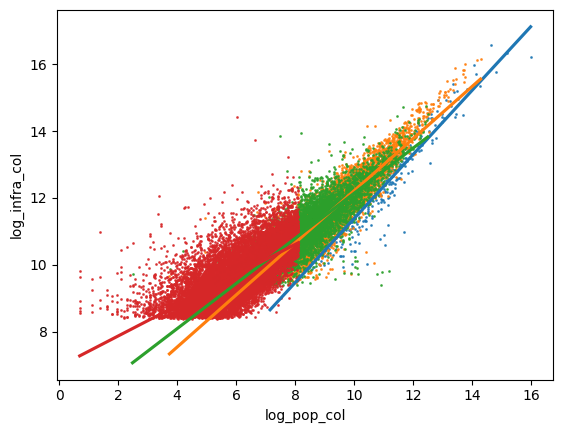

In [21]:
current_stock_col ='cl_total_length'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030


df_for_analysis = roads_clean[['GEOID', 'State', 'NAMELSAD','city type', 'citytype_at_2030', 'citytype_at_2040',
                                'citytype_at_2050', 'citytype_at_2060', 'CensusPop_20', 'ssp22020', 'ssp22030', 
                                'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100','cl_total_length']]

df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2030, on ='GEOID')
print(roads_clean.shape)

In [22]:
df_for_analysis.columns

Index(['GEOID', 'State', 'NAMELSAD', 'city type', 'citytype_at_2030',
       'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060',
       'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050',
       'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'cl_total_length', 'per_cap_mass_t1', 'per_cap_mass_at_2030',
       'cl_length_at_2030'],
      dtype='object')

(31169, 22)
Initial dataframe:====
(31169, 22)
Shape of the dataframe for urban:====
(324, 22)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(291, 22)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     2268.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          7.79e-139
Time:                        19:19:42   Log-Likelihood:                -206.69
No. Observations:                 291   AIC:                             417.4
Df Residuals:                     289   BIC:                             424.7
Df Model:                           1                                         
Covariance Type:      

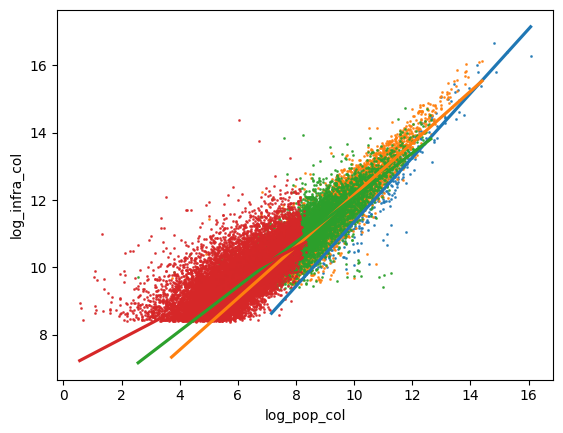

In [23]:
current_stock_col ='cl_length_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2040, on ='GEOID')
print(roads_clean.shape)

(31169, 24)
Initial dataframe:====
(31169, 24)
Shape of the dataframe for urban:====
(330, 24)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(297, 24)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     2294.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          3.52e-141
Time:                        19:20:43   Log-Likelihood:                -213.13
No. Observations:                 297   AIC:                             430.3
Df Residuals:                     295   BIC:                             437.6
Df Model:                           1                                         
Covariance Type:      

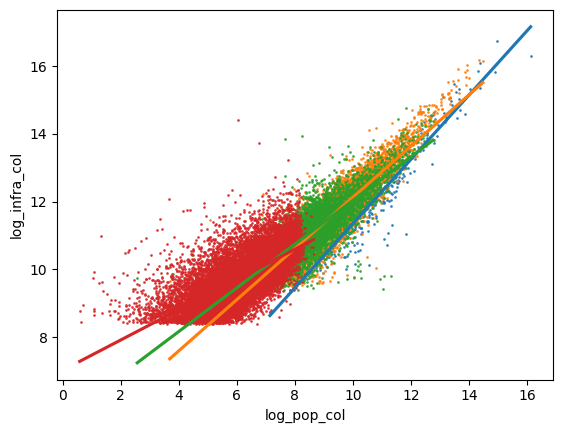

In [24]:
current_stock_col ='cl_length_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2050, on ='GEOID')
print(roads_clean.shape)

(31169, 26)
Initial dataframe:====
(31169, 26)
Shape of the dataframe for urban:====
(334, 26)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(300, 26)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     2259.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          4.02e-141
Time:                        19:21:43   Log-Likelihood:                -218.21
No. Observations:                 300   AIC:                             440.4
Df Residuals:                     298   BIC:                             447.8
Df Model:                           1                                         
Covariance Type:      

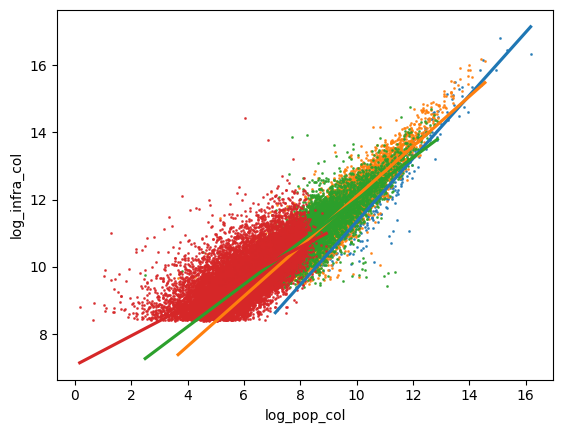

In [25]:
current_stock_col ='cl_length_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2060, on ='GEOID')
print(roads_clean.shape)

(31169, 28)
Initial dataframe:====
(31169, 28)
Shape of the dataframe for urban:====
(337, 28)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(303, 28)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     2215.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          8.10e-141
Time:                        19:22:45   Log-Likelihood:                -225.48
No. Observations:                 303   AIC:                             455.0
Df Residuals:                     301   BIC:                             462.4
Df Model:                           1                                         
Covariance Type:      

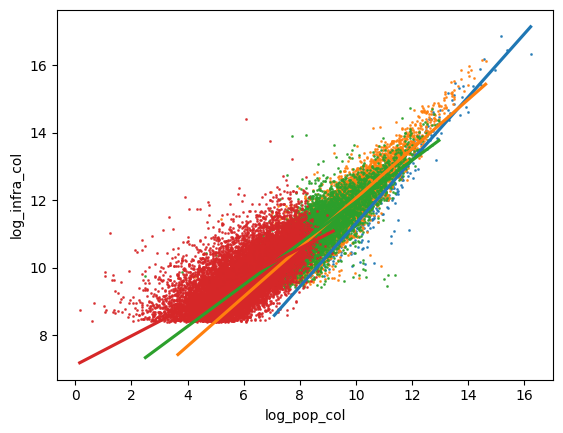

In [26]:
current_stock_col ='cl_length_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2070, on ='GEOID')
print(roads_clean.shape)

In [36]:
roads_clean[['State', 'NAMELSAD', 'per_cap_mass_20', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060','per_cap_mass_at_2070']]

,State,NAMELSAD,per_cap_mass_20,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060,per_cap_mass_at_2070
0,1.0,Ardmore town,21.007126,18.900410,17.434026,16.330812,15.390307,14.588023
1,1.0,Mooresville town,68.116426,60.714920,55.147067,51.060172,47.556448,44.565476
2,1.0,Somerville town,36.400175,35.944437,36.362255,37.261280,38.205885,39.328976
3,1.0,Trinity town,19.651329,19.313741,19.261055,19.367542,19.382584,19.418883
4,1.0,Goshen town,57.964545,55.722598,54.651707,53.905327,52.985110,52.060640
...,...,...,...,...,...,...,...,...
31164,56.0,Westview Circle CDP,174.477356,168.657365,164.824934,161.985149,157.586107,153.874591
31165,56.0,Whiting CDP,77.898333,75.067317,73.731107,71.958269,69.220257,66.237554
31166,56.0,Wilson CDP,48.155186,42.832854,39.161357,36.096565,33.544393,31.433069
31167,56.0,Woods Landing-Jelm CDP,344.963383,302.750251,268.517472,239.102079,212.727179,190.033047


(312, 49)


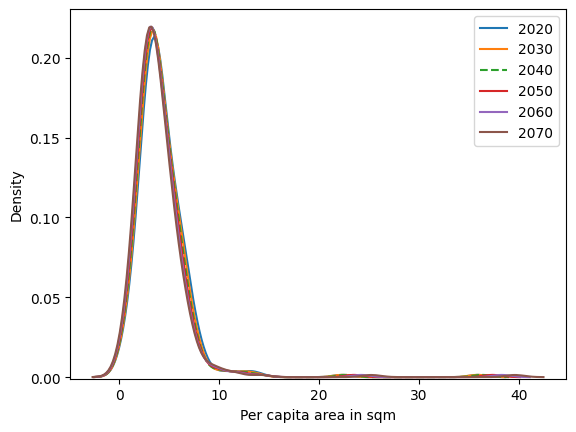

In [28]:
df_plot_city = roads_clean[roads_clean['city type'] == 'urban']
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2070')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2080')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

(6887, 49)
Plotting 95 percentile values
(6542, 49)


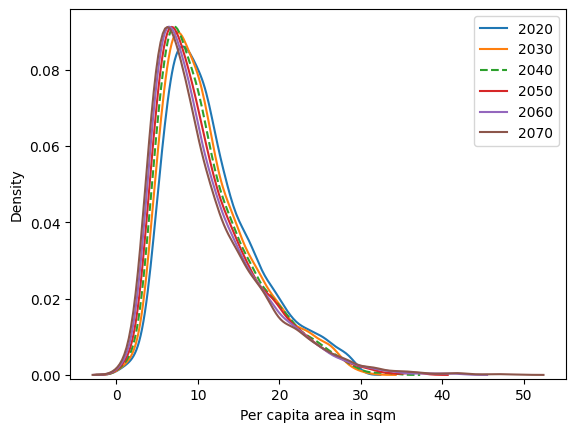

In [30]:
df_plot_city = roads_clean[roads_clean['city type'] == 'suburban']
print(df_plot_city.shape)
print("Plotting 95 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.95)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2070')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

(5712, 49)
Plotting 95 percentile values
(5426, 49)


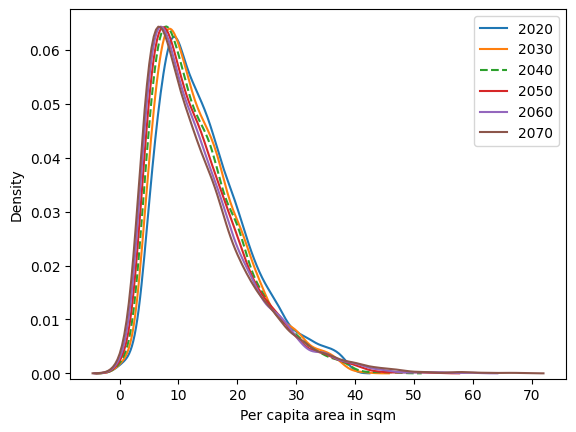

In [31]:
df_plot_city = roads_clean[roads_clean['city type'] == 'periurban']
print(df_plot_city.shape)
print("Plotting 95 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.95)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2070')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

(18258, 49)
Plotting 80 percentile values
(14606, 49)


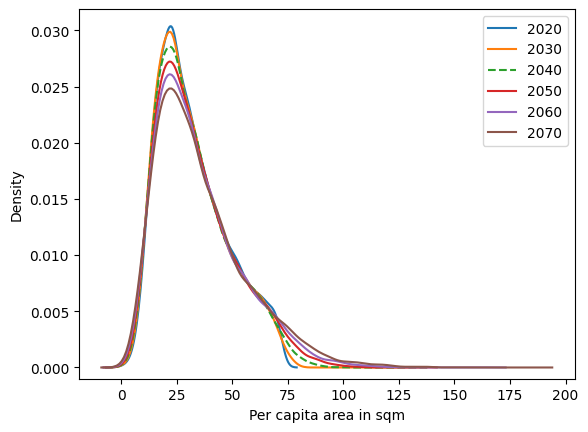

In [35]:
df_plot_city = roads_clean[roads_clean['city type'] == 'rural']
print(df_plot_city.shape)
print("Plotting 80 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.80)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2070')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

In [43]:
# df_stocks_iter = pd.DataFrame()

# for i in range(10):

#     roads_with_pop['per_cap_mass_20'] =  roads_with_pop['total_length'] / roads_with_pop['CensusPop_20']
#     stocks_with_pop_main = roads_with_pop[roads_with_pop['CensusPop_20'] != 0]
#     stocks_with_pop = stocks_with_pop_main[stocks_with_pop_main['city type'] == 'urban']
#     print(stocks_with_pop.shape)

#     current_stock_col ='total_length'
#     current_pop_col = 'CensusPop_20'
#     next_pop_col = 'ssp22030'

#     ### ============== PRUNING ============== ### top and bottom 10 %
#     # Set the threshold to the 90th percentile
#     threshold_upper = stocks_with_pop[current_stock_col].quantile(0.9)
#     threshold_lower = stocks_with_pop[current_stock_col].quantile(0.1)
#     # Filter the DataFrame to include only points in the to 10%
#     stocks_with_pop = stocks_with_pop[stocks_with_pop[current_stock_col] < threshold_upper]
#     # stocks_with_pop = stocks_with_pop[stocks_with_pop[current_stock_col] > threshold_lower]
#     print(stocks_with_pop.shape)



#     df_2030 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2030', 
#                                     'per_cap_mass_t2': 'per_cap_mass_30'}, inplace = True)


#     current_stock_col ='surface_Res_2030'
#     current_pop_col = 'ssp22030'
#     next_pop_col = 'ssp22040'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2040', 
#                                     'per_cap_mass_t2': 'per_cap_mass_40'}, inplace = True)

#     current_stock_col ='surface_Res_2040'
#     current_pop_col = 'ssp22040'
#     next_pop_col = 'ssp22050'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2050', 
#                                     'per_cap_mass_t2': 'per_cap_mass_50'}, inplace = True)

#     current_stock_col ='surface_Res_2050'
#     current_pop_col = 'ssp22050'
#     next_pop_col = 'ssp22060'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2060', 
#                                     'per_cap_mass_t2': 'per_cap_mass_60'}, inplace = True)

#     current_stock_col ='surface_Res_2060'
#     current_pop_col = 'ssp22060'
#     next_pop_col = 'ssp22070'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2070', 
#                                     'per_cap_mass_t2': 'per_cap_mass_70'}, inplace = True)

#     current_stock_col ='surface_Res_2070'
#     current_pop_col = 'ssp22070'
#     next_pop_col = 'ssp22080'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2080', 
#                                     'per_cap_mass_t2': 'per_cap_mass_80'}, inplace = True)  
    
    
#     current_stock_col ='surface_Res_2080'
#     current_pop_col = 'ssp22080'
#     next_pop_col = 'ssp22090'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2090', 
#                                     'per_cap_mass_t2': 'per_cap_mass_90'}, inplace = True)  
    

#     current_stock_col ='surface_Res_2090'
#     current_pop_col = 'ssp22090'
#     next_pop_col = 'ssp22100'

#     df_2040 = find_next_stock(stocks_with_pop, current_stock_col,current_pop_col, next_pop_col)

#     stocks_with_pop.rename(columns = {'stock_next_time_step' :'surface_Res_2100', 
#                                     'per_cap_mass_t2': 'per_cap_mass_100'}, inplace = True)  

#     df_stocks_iter = pd.concat([df_stocks_iter,stocks_with_pop[['NAMELSAD', 'State', 'per_cap_mass_20', 'per_cap_mass_30','per_cap_mass_40', 'per_cap_mass_50', 'per_cap_mass_60',
#                                                                 'per_cap_mass_70','per_cap_mass_80', 'per_cap_mass_90', 'per_cap_mass_100']]], axis=1)

In [44]:
# column_for_min_max_plot = 'per_cap_mass_100'
# df_stocks_iter['min_per_cap_mass'] = df_stocks_iter[column_for_min_max_plot].min(axis=1)
# df_stocks_iter['max_per_cap_mass'] = df_stocks_iter[column_for_min_max_plot].max(axis=1)
# df_stocks_iter['avg_per_cap_mass'] = df_stocks_iter[column_for_min_max_plot].mean(axis=1)

# sns.kdeplot(data=df_stocks_iter, x = 'max_per_cap_mass')
# sns.kdeplot(data=df_stocks_iter, x = 'min_per_cap_mass')
# sns.kdeplot(data=df_stocks_iter, x = 'avg_per_cap_mass')
# plt.legend(labels=['max', 'min', 'avg'])